# FHE SDK resultados #2

Este notebook analiza los resultados del segundo caso del benchmark de nuestra SDK de
cifrado homomórfico, comparándola contra dos implementaciones de la industria sobre una
tarea de clasificación de imágenes. El objetivo es el mismo que en el caso anterior:
cuantificar el costo del cifrado en tres dimensiones — **calidad de predicción**,
**latencia**, y **consumo de memoria** — pero ahora sobre una red más profunda y con
una capa convolucional.

## Red y dataset

El caso se llama **cnn** porque la red es una *red neuronal convolucional* (CNN,
convolutional neural network): un tipo de red que aplica filtros de convolución sobre la
entrada para detectar patrones espaciales locales (bordes, formas), seguido de una capa
totalmente conectada que produce las puntuaciones por clase. La arquitectura usada es
deliberadamente *poco profunda* para que el costo del cifrado sea manejable:

`Conv2d(1 → 4, kernel 7, stride 5) → ReLU → Flatten → Linear(100 → 10)`

La salida es un vector de 10 puntuaciones (una por dígito); la predicción es la clase con
puntuación máxima. Es un **modelo de clasificación**.

Se entrena sobre **MNIST**: 70 000 imágenes de 28×28 píxeles en escala de grises con dígitos
manuscritos del 0 al 9. Las imágenes se normalizan al rango [0, 1] dividiendo por 255 y luego
se estandarizan con la media y desviación del split de entrenamiento.

## Backends comparados

- **pytorch_plain**: baseline en claro, sin cifrado.
- **[sdk](https://github.com/Rcontre360/thesis-ucv-FHE)**: nuestra SDK CKKS sobre HEonGPU.
- **[concrete-ml](https://github.com/zama-ai/concrete-ml)**: TFHE de Zama, cuantizado a 6 bits.
- **[orion](https://github.com/baahl-nyu/orion/tree/main/orion)**: CKKS sobre Lattigo (Go) con bootstrapping.

## Metodología de medición

Cada backend se ejecuta en un **proceso independiente** y en su propio entorno virtual de
Python. Esta separación es necesaria por dos razones. Primero, hay conflictos de
dependencias entre librerías (Concrete-ML fija PyTorch 2.3, Orion exige 2.4 o superior). Y
segundo, al aislar cada corrida en su propio proceso se garantiza que el pico de VRAM y RAM
medido para un backend no se contamine con la memoria que otro dejó reservada durante una
ejecución previa. Un orquestador lanza cada subproceso de forma secuencial, recoge sus
métricas en formato estructurado y las consolida en un único CSV de resultados.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mp

HERE = Path.cwd()
RESULTS = HERE / "results"

df = pd.read_csv(RESULTS / "results_cnn.csv")
profile = pd.read_csv(RESULTS / "profile_sdk_cnn.csv")

PALETTE = {"pytorch_plain": "#888", "sdk": "#3a7", "concrete-ml": "#e84", "orion": "#39c"}
colors = [PALETTE[b] for b in df["backend"]]
PHASES = ["keygen", "compile", "infer"]

df

,backend,float_accuracy,approx_accuracy,accuracy,agreement,output_mae,precision_bits,keygen_s,compile_s,latency_s,...,compile_vram_delta_mb,compile_vram_alloc_mb,compile_vram_alloc_delta_mb,compile_ram_mb,infer_vram_mb,infer_vram_delta_mb,infer_vram_alloc_mb,infer_vram_alloc_delta_mb,infer_ram_mb,setup_s
0,pytorch_plain,0.939286,0.925,0.925,1.0,0.000000,NaN,0.000000,0.000000,0.001452,...,0.0,0.000000,0.000000,0.000000,320.2500,0.0000,0.382324,0.0,804.660156,0.000000
1,sdk,0.939286,0.860,0.400,0.6,91.178940,-6.510629,39.933742,1.515450,28.309954,...,0.0,2861.304947,2472.502106,44600.000000,21950.2500,0.0000,3120.304947,259.0,44600.000000,41.449192
2,concrete-ml,0.939286,0.850,0.850,1.0,0.332189,1.589925,3.028044,34.032187,448.876024,...,0.0,0.000000,0.000000,971.316406,527.5625,263.3125,0.000000,0.0,4371.828125,37.060231
3,orion,0.939286,0.880,0.800,1.0,0.003198,8.288445,5.267607,156.679857,46.487499,...,0.0,0.000000,0.000000,35257.214844,525.5625,261.3125,0.000000,0.0,35257.214844,161.947464


## 1. Calidad de la inferencia (exactitud)

La calidad se mide con la **exactitud** (accuracy), estándar para tareas de clasificación:
la proporción de samples cuya clase predicha coincide con la etiqueta real. Una exactitud de
1.0 corresponde a un clasificador perfecto y una de 0.1 al rendimiento esperado por azar en
10 clases balanceadas como MNIST.

Para cada backend FHE se reportan **dos** medidas de exactitud, porque hay dos fuentes
distintas de error que conviene separar:

| Métrica | Qué representa |
|---|---|
| `approx_accuracy` | Exactitud del modelo después de **aproximarlo para que sea compatible con FHE**, evaluado en claro (sin cifrado). En la SDK y Orion la ReLU se reemplaza por una composición de polinomios; en Concrete-ML toda la red se cuantiza a 6 bits. Esta etapa es la misma con o sin cifrado, así que aísla el costo de la transformación. |
| `accuracy`        | Exactitud del modelo aproximado evaluado **bajo cifrado real**, sobre los samples de latencia. Mide el ruido adicional que introduce el esquema FHE en sí mismo: errores de redondeo, ruido del bootstrapping, pérdida de precisión a lo largo de la cadena de operaciones. |

La diferencia entre la columna PyTorch y `approx_accuracy` muestra **cuánto cuesta aproximar
la red para que sea representable en el esquema**. La diferencia entre `approx_accuracy` y
`accuracy` muestra **cuánto cuesta el cifrado en sí mismo** sobre esa red ya aproximada. Son
dos fenómenos independientes: una red puede aproximarse muy bien y cifrarse mal, o al revés.

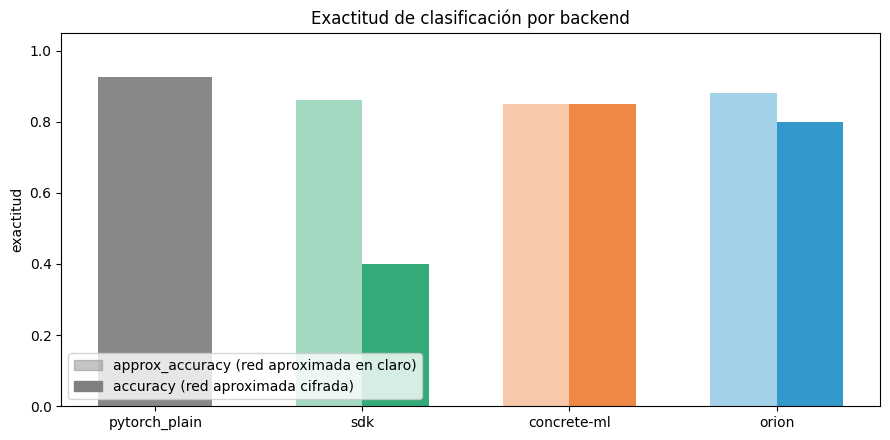

In [2]:
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(df))
for i, (_, row) in enumerate(df.iterrows()):
    color = PALETTE[row["backend"]]
    if row["backend"] == "pytorch_plain":
        ax.bar(i, row["accuracy"], 0.55, color=color)
    else:
        ax.bar(i - 0.16, row["approx_accuracy"], 0.32, color=color, alpha=0.45)
        ax.bar(i + 0.16, row["accuracy"],        0.32, color=color)
ax.set_xticks(x); ax.set_xticklabels(df["backend"]) 
ax.set_ylabel("exactitud"); ax.set_ylim(0, 1.05)
ax.set_title("Exactitud de clasificación por backend")
ax.legend(handles=[
    mp.Patch(color="gray", alpha=0.45, label="approx_accuracy (red aproximada en claro)"),
    mp.Patch(color="gray",             label="accuracy (red aproximada cifrada)"),
], loc="lower left")
plt.tight_layout(); plt.show()

## 2. Fidelidad numérica vs. PyTorch

La exactitud mide aciertos contra la etiqueta real. Esta sección mide una pregunta distinta:
**¿qué tan parecidas son las puntuaciones (logits) producidas por la red cifrada a las que
produciría el modelo PyTorch en claro sobre el mismo input?**.

Se reporta el **error absoluto medio** (`output_mae`) entre los logits cifrados y los logits
PyTorch, promediado sobre todos los samples y todas las clases. Un `output_mae` cercano a
cero significa que el cifrado preserva fielmente la salida del modelo original; un valor
grande indica que el ruido FHE está distorsionando significativamente los logits. Esto es
complementario a la exactitud: una red puede mantener buena exactitud aunque sus logits
estén ruidosos (mientras el orden relativo entre clases se preserve), y viceversa — logits
muy precisos pero con un sesgo sistemático pueden bajar la exactitud.

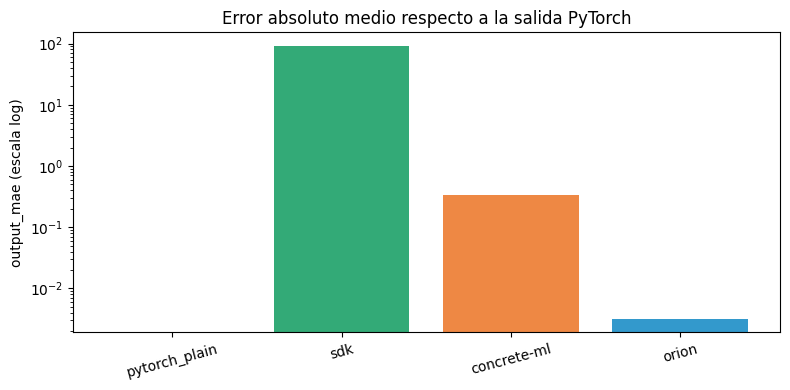

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(df["backend"], df["output_mae"], color=colors)
ax.set_yscale("log"); ax.set_ylabel("output_mae (escala log)")
ax.set_title("Error absoluto medio respecto a la salida PyTorch")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout(); plt.show()

## 3. Latencia de inferencia

Tiempo promedio por sample para una inferencia cifrada **extremo a extremo**: cifrar el
input, ejecutar la red cifrada y descifrar la salida. El cronómetro se sincroniza con la
GPU antes y después de cada bloque medido, así que el tiempo refleja trabajo real terminado,
no operaciones encoladas asincrónicamente.

Se usa escala logarítmica porque los rangos típicos abarcan varios órdenes de magnitud:
milisegundos para PyTorch, decenas de segundos para la SDK y Orion, y minutos para
Concrete-ML en esta arquitectura.

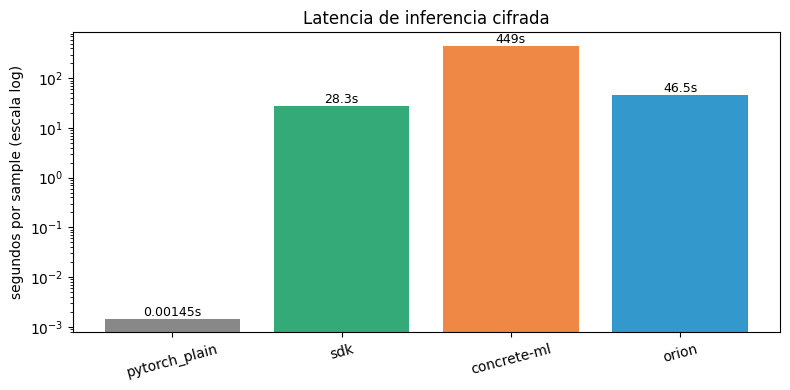

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(df["backend"], df["latency_s"], color=colors)
ax.set_yscale("log"); ax.set_ylabel("segundos por sample (escala log)")
ax.set_title("Latencia de inferencia cifrada")
ax.tick_params(axis="x", rotation=15)
for b, v in zip(bars, df["latency_s"]):
    ax.text(b.get_x() + b.get_width()/2, v, f"{v:.3g}s", ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()

## 4. Fases del benchmark

Antes de mostrar las métricas de setup y memoria, conviene definir las tres fases en las que
se descompone cada corrida. Todas las métricas posteriores están reportadas por fase.

| Fase | Qué ocurre | Frecuencia |
|---|---|---|
| **keygen** | Generación de las claves criptográficas: clave secreta, pública, de relinealización, de Galois (rotaciones) y de bootstrapping cuando aplica. | Una vez por contexto FHE. |
| **compile** | Preparación del modelo para inferencia cifrada: calibración con datos de entrenamiento, ajuste de los polinomios que aproximan las activaciones no-lineales, *packing* de las matrices de pesos en el formato del esquema, asignación de niveles. | Una vez por modelo. |
| **infer** | Inferencia cifrada sobre un sample: cifrado del input, forward pass cifrado, descifrado del output. | Cada predicción. |

El keygen y el compile son costos fijos amortizables sobre todas las inferencias posteriores;
solo el infer escala con el volumen de datos a predecir.

### Setup (keygen + compile)

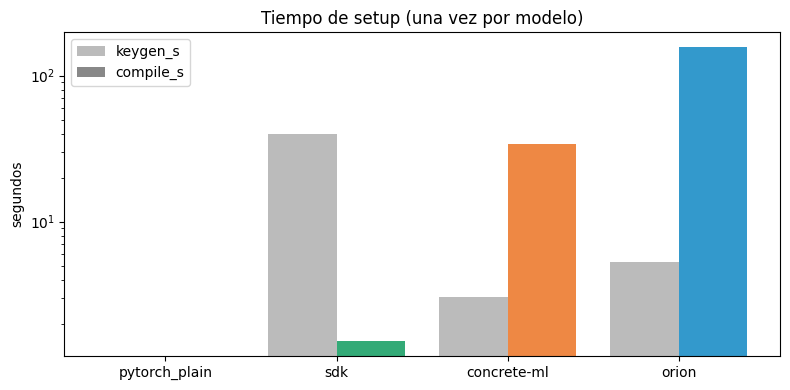

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(df))
w = 0.4
ax.bar(x - w/2, df["keygen_s"],  w, label="keygen_s",  color="#bbb")
ax.bar(x + w/2, df["compile_s"], w, label="compile_s", color=colors)
ax.set_xticks(x); ax.set_xticklabels(df["backend"]) 
ax.set_ylabel("segundos"); ax.set_yscale("log")
ax.set_title("Tiempo de setup (una vez por modelo)")
ax.legend(); plt.tight_layout(); plt.show()

## 5. Memoria GPU (VRAM)

Por cada una de las tres fases (keygen, compile, infer) se reportan **dos** medidas
complementarias de VRAM:

| Métrica | Qué representa |
|---|---|
| `<fase>_vram_mb` | Pico de VRAM observado **a nivel del dispositivo**. Incluye toda la memoria que el proceso le tiene reservada al GPU: datos del cálculo, fragmentación del pool, contexto del runtime CUDA, buffers internos del driver. Es la métrica que coincide con `nvidia-smi`. |
| `<fase>_vram_alloc_mb` | Pico del **conjunto de memoria efectivamente reservada por el backend para datos del cálculo**, según su propio contador interno. Es más limpio porque excluye overhead del runtime y memoria pre-asignada al pool que no llegó a usarse. Disponible solo cuando el backend expone este contador: actualmente la SDK (vía RMM) y PyTorch; aparece como cero para Concrete-ML y Orion. |

Cuando ambas métricas están disponibles, su comparación es informativa: si la diferencia es
grande, indica que el backend está pre-asignando mucha memoria a su pool pero usando poco; si
están cerca, el pool está utilizado eficientemente.

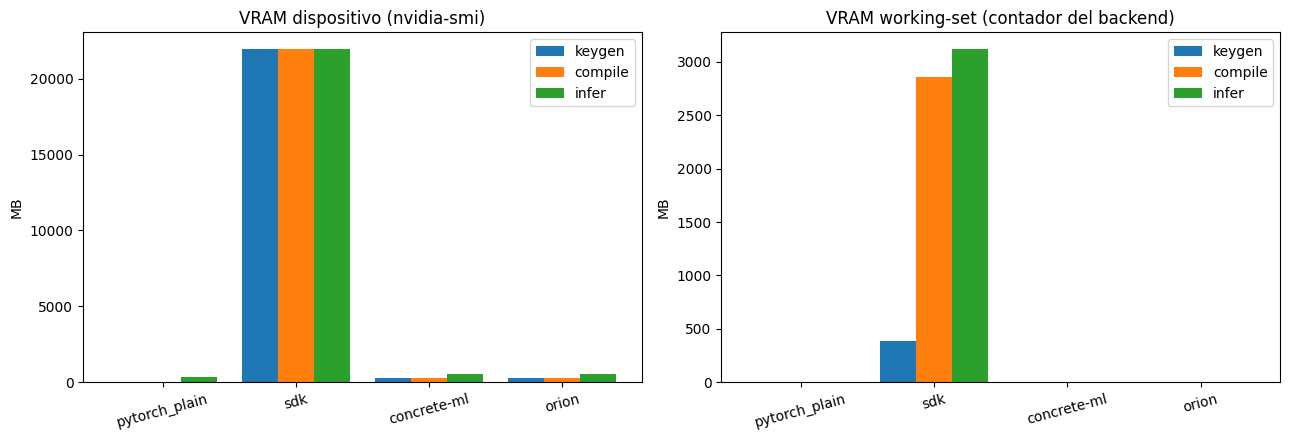

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
x = np.arange(len(df))
w = 0.27
for i, p in enumerate(PHASES):
    axes[0].bar(x + (i-1)*w, df[f"{p}_vram_mb"], w, label=p)
    axes[1].bar(x + (i-1)*w, df[f"{p}_vram_alloc_mb"], w, label=p)
for ax, title in zip(axes, ["VRAM dispositivo (nvidia-smi)", "VRAM working-set (contador del backend)"]):
    ax.set_xticks(x); ax.set_xticklabels(df["backend"]) 
    ax.set_ylabel("MB"); ax.set_title(title); ax.legend()
    ax.tick_params(axis="x", rotation=15)
plt.tight_layout(); plt.show()

## 6. Memoria RAM del host

La memoria RAM se mide como el **conjunto residente** (RSS) del proceso de cada backend:
la cantidad de memoria física que el sistema operativo le tiene asignada al proceso en un
momento dado. Es el mismo número que reporta `top` o `htop` para ese PID.

Hay un detalle importante de interpretación: el RSS pico es **monotónico** durante toda la
corrida del proceso — siempre crece o se mantiene, nunca decrece, porque registra el máximo
histórico hasta el momento. Esto significa que `<fase>_ram_mb` **no** es "cuánta RAM consumió
esta fase", sino "cuánto era el pico hasta el final de esta fase". Para estimar el costo
aislado de una fase hay que mirar el incremento respecto a la fase anterior.

El proceso del backend también incluye el intérprete de Python, PyTorch, NumPy y todas las
librerías cargadas, así que incluso una corrida que no haga nada con datos ya parte de un
baseline de varios cientos de MB. El interés está en las **diferencias entre backends y entre
fases**, no en los valores absolutos.

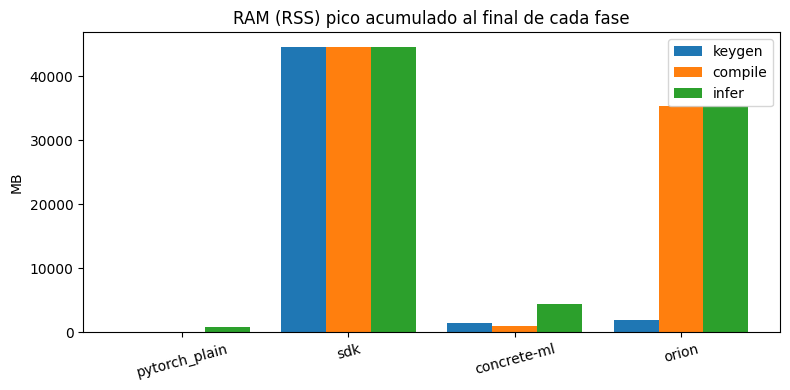

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(df))
w = 0.27
for i, p in enumerate(PHASES):
    ax.bar(x + (i-1)*w, df[f"{p}_ram_mb"], w, label=p)
ax.set_xticks(x); ax.set_xticklabels(df["backend"]) 
ax.set_ylabel("MB"); ax.set_title("RAM (RSS) pico acumulado al final de cada fase")
ax.tick_params(axis="x", rotation=15); ax.legend()
plt.tight_layout(); plt.show()

## 7. Perfil por capa de la SDK

Una corrida adicional, complementaria al benchmark principal, ejecuta el modelo de la SDK
capa por capa con un solo sample, midiendo el tiempo y la memoria de cada operador por
separado. Esto identifica los cuellos de botella dentro del modelo cifrado y permite
comparar el costo relativo de capas convolucionales vs. activaciones polinómicas vs. capas
lineales (las activaciones polinómicas son típicamente dominantes en CKKS).

| Columna | Qué representa |
|---|---|
| `time_s` | Tiempo de ejecución de la capa, medido entre sincronizaciones con la GPU. |
| `mem_after_mb` | VRAM total ocupada por el pool del backend después de ejecutar la capa. |

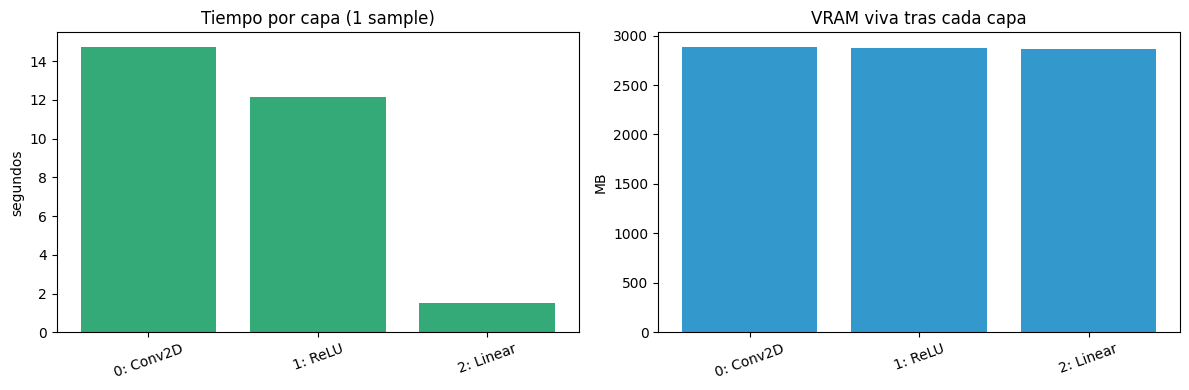

,layer_idx,layer_name,time_s,mem_delta_mb,mem_after_mb
0,0,Conv2D,14.756757,-1.0,2888.304947
1,1,ReLU,12.170036,-15.0,2873.304947
2,2,Linear,1.523933,-6.0,2867.304947


In [8]:
labels = [f"{i}: {n}" for i, n in zip(profile["layer_idx"], profile["layer_name"])]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(labels, profile["time_s"], color="#3a7")
axes[0].set_ylabel("segundos"); axes[0].set_title("Tiempo por capa (1 sample)")
axes[0].tick_params(axis="x", rotation=20)
axes[1].bar(labels, profile["mem_after_mb"], color="#39c")
axes[1].set_ylabel("MB"); axes[1].set_title("VRAM viva tras cada capa")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()

profile